# SVR

El objetivo es predecir el precio de una casa dados sus atributos, utilizando modelos de SVR.

##### Bibliotecas necesarias

In [ ]:
#General
import numpy as np
import pandas as pd
from skimpy import skim

#Estadisticas
from scipy import stats

#Graficas
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from pandas.plotting import andrews_curves


#Valores atipicos
from pyod.models.mcd import MCD

#Modelo de regresion 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  MinMaxScaler
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

#### Global Options

In [2]:
np.random.seed(1989)

In [3]:
pd.options.display.float_format = '{:,.3f}'.format

## Carga de datos

El conjunto de datos consta de las siguientes variables:

* Superficie: La superficie total de la casa en pies cuadrados.
* Dormitorios: El número de dormitorios de la casa.
* Baños: El número de baños de la casa.
* Plantas: El número de plantas de la casa.
* Calle principal: Si la casa está conectada a la calle principal (Sí/No).
* Habitación: Si la casa tiene habitación (Sí/No).
* Sótano: Si la casa tiene sótano (Sí/No).
* Calentador de agua: Si la casa tiene calentador de agua (Sí/No).
* Aire acondicionado: Si la casa tiene aire acondicionado (Sí/No).
* Aparcamiento: El número de plazas de aparcamiento disponibles dentro de la casa.
* Prefacio: Si la casa está ubicada en una zona preferida (Sí/No).
* Estado del mobiliario: El estado del mobiliario de la casa (Totalmente amueblado, Semiamueblado, Sin amueblar).

La variable objetivo es: **Precio** (en dólares).

In [4]:
#Cargamos los datos
df = pd.read_csv(r"C:\Users\raulb\Desktop\Diplomado\Modulo2\Datos\Housing.csv")

In [5]:
df.sample(15)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
172,5250000,8400,3,1,2,yes,yes,yes,no,yes,2,yes,unfurnished
247,4550000,8400,4,1,4,yes,no,no,no,no,3,no,unfurnished
284,4270000,7770,2,1,1,yes,no,no,no,no,1,no,furnished
60,7140000,6000,3,2,2,yes,yes,no,no,no,1,no,semi-furnished
173,5250000,5300,4,2,1,yes,no,no,no,yes,0,yes,unfurnished
128,5873000,5500,3,1,3,yes,yes,no,no,yes,1,no,furnished
205,4900000,6300,3,1,1,yes,no,no,no,yes,2,no,semi-furnished
412,3430000,2610,3,1,2,yes,no,yes,no,no,0,yes,unfurnished
58,7210000,7680,4,2,4,yes,yes,no,no,yes,1,no,semi-furnished
216,4830000,6040,3,1,1,yes,no,no,no,no,2,yes,semi-furnished


In [6]:
#Definimos las variables numericas y categoricas
var_num = ["price", "area", "bedrooms", "bathrooms", "stories", "parking"]
var_cat = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea", "furnishingstatus"]

In [7]:
#Transformamos mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea y furnishingstatus
for var in var_cat:
    df[var] = df[var].astype("category")

In [8]:
#Resumen de los datos
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types               Categories                                        │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━┓                                │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables ┃                                │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━┩                                │
│ │ Number of rows    │ 545    │ │ category    │ 7     │ │ mainroad              │                                │
│ │ Number of columns │ 13     │ │ int64       │ 6     │ │ guestroom             │                                │
│ └───────────────────┴────────┘ └─────────────┴───────┘ │ basement              │                                │
│                                                        │ hotwaterheating       │                                │
│                                                        │ airconditioning       │                                │
│                                                        │ prefarea              │                                │
│                                                        │ furnishingstatus      │                                │
│                                                        └───────────────────────┘                                │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column     ┃ NA  ┃ NA %  ┃ mean     ┃ sd       ┃ p0      ┃ p25     ┃ p50     ┃ p75     ┃ p100     ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━┩  │
│ │ price      │   0 │     0 │  4767000 │  1870000 │ 1750000 │ 3430000 │ 4340000 │ 5740000 │ 13300000 │  ▆▇▃▁  │  │
│ │ area       │   0 │     0 │     5151 │     2170 │    1650 │    3600 │    4600 │    6360 │    16200 │  ▇▇▃▁  │  │
│ │ bedrooms   │   0 │     0 │    2.965 │   0.7381 │       1 │       2 │       3 │       3 │        6 │   ▃▇▃  │  │
│ │ bathrooms  │   0 │     0 │    1.286 │   0.5025 │       1 │       1 │       1 │       2 │        4 │  ▇ ▃   │  │
│ │ stories    │   0 │     0 │    1.806 │   0.8675 │       1 │       1 │       2 │       2 │        4 │ ▇ ▇ ▁▁ │  │
│ │ parking    │   0 │     0 │   0.6936 │   0.8616 │       0 │       0 │       0 │       1 │        3 │ ▇ ▃ ▃  │  │
│ └────────────┴─────┴───────┴──────────┴──────────┴─────────┴─────────┴─────────┴─────────┴──────────┴────────┘  │
│                                                    category                                                     │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓  │
│ ┃ column                                   ┃ NA       ┃ NA %         ┃ ordered             ┃ unique          ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩  │
│ │ mainroad                                 │        0 │            0 │ False               │               2 │  │
│ │ guestroom                                │        0 │            0 │ False               │               2 │  │
│ │ basement                                 │        0 │            0 │ False               │               2 │  │
│ │ hotwaterheating                          │        0 │            0 │ False               │               2 │  │
│ │ airconditioning                          │        0 │            0 │ False               │               2 │  │
│ │ prefarea                                 │        0 │            0 │ False               │               2 │  │
│ │ furnishingstatus                         │        0 

No hay valores ausentes.

## EDA

### Gráficos y correlación

In [9]:
#Definimos un objeto para graficar
class analyze:
    # Inicializamos la clase
    def __init__(self, df, num_vars, cat_vars):
        self.df = df
        self.num_vars = num_vars
        self.cat_vars = cat_vars

    #Método para graficar variables numéricas
    def plot_num(self):
        for var in self.num_vars:
            fig = make_subplots(rows=1, cols=2)

            # Boxplot
            fig.add_trace(
                go.Box(y=self.df[var], name="Boxplot", marker_color="#de3163"),
                row=1, col=1
            )

            # Histograma
            fig.add_trace(
                go.Histogram(x=self.df[var], name="Histograma",
                             marker_color="#31deac", nbinsx=50,
                             histnorm='probability density'),
                row=1, col=2
            )

            fig.update_layout(title_text=f"Variable: {var}", height=400, width=800)
            fig.show()

    #Método para graficar variables categóricas
    def plot_cat(self):
        for var in self.cat_vars:
            value_counts = self.df[var].value_counts()
            labels = value_counts.index.astype(str)
            values = value_counts.values

            fig = go.Figure(
                data=[go.Pie(labels=labels, values=values,textinfo='label+value+percent',
                    marker=dict(colors=["#de3163", "#31deac"])
                                )
                    ]
            )

            fig.update_layout(title_text=f"Variable: {var}", height=400, width=500)
            fig.show()

    #Método para graficar la matriz de correlación de numéricas
    def corr_matrix(self):
        corr_matrix = self.df[self.num_vars].corr()

        fig = go.Figure(data=go.Heatmap(
            z=corr_matrix.values,
            x=corr_matrix.columns,
            y=corr_matrix.columns,
            colorscale='Inferno'))

        fig.update_layout(
            title='Matriz de Correlación',
            width=800,
            height=600
        )

        fig.show()

In [10]:
#Definimos la Curva de Andrews escalada
def andrews_curve_scaled(df):
    df_aux = df.copy()
    
    #Escalamos solo las columnas numéricas
    numeric_cols = df_aux.select_dtypes(include=['float64', 'int64']).columns
    scaler = MinMaxScaler()
    df_aux[numeric_cols] = scaler.fit_transform(df_aux[numeric_cols])
    
    #Agregamos una categoría ficticia
    df_aux["dummy_class"] = ""
    
    plt.figure(figsize=(12,8))
    andrews_curves(df_aux, "dummy_class", colormap="viridis", alpha=0.2)
    plt.title("Curvas de Andrews")
    plt.xlabel("t (función de Fourier)")
    plt.ylabel("Valor transformado")
    plt.grid(True, color="lightgray", linestyle="--", linewidth=0.5)
    plt.show()

In [11]:
analisis = analyze(df, var_num, var_cat)

In [12]:
analisis.plot_num()

In [13]:
analisis.plot_cat()

In [14]:
analisis.corr_matrix()

De lo anterior podemos describir lo siguiente:
* El mínimo de precio es de 1 millón 750 mil dólares; el máximo es de 13 millones 300 mil. Se tiene una desviación estándar de 1 millón 870 mil dólares. 
  En consecuencia, el precio tiene una variabilidad alta y sesgada hacia valores pequeños. Existen más casas con precios bajos o medios que altos. 

* El área también tiene una variabilidad alta. Hay más casas con áreas pequeñas/medias que grandes. 

* El número de habitaciones va de 1 a 6. 

* El número de baños va de 1 a 4. 

* El número de plantas va de 1 a 4. 

* Los lugares de estacionamiento van de 0 a 3. 

* Eliminaremos hotwater, pues hay una dominancia mayor al 90%.

* No hay problemas de multicolinealidad.

* La mayoría de casas tienen tres habitaciones, un baño, dos plantas y cero lugares de estacionamiento.

#### Valores Atípicos

c:\Users\raulb\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\plotting\_matplotlib\misc.py:286: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



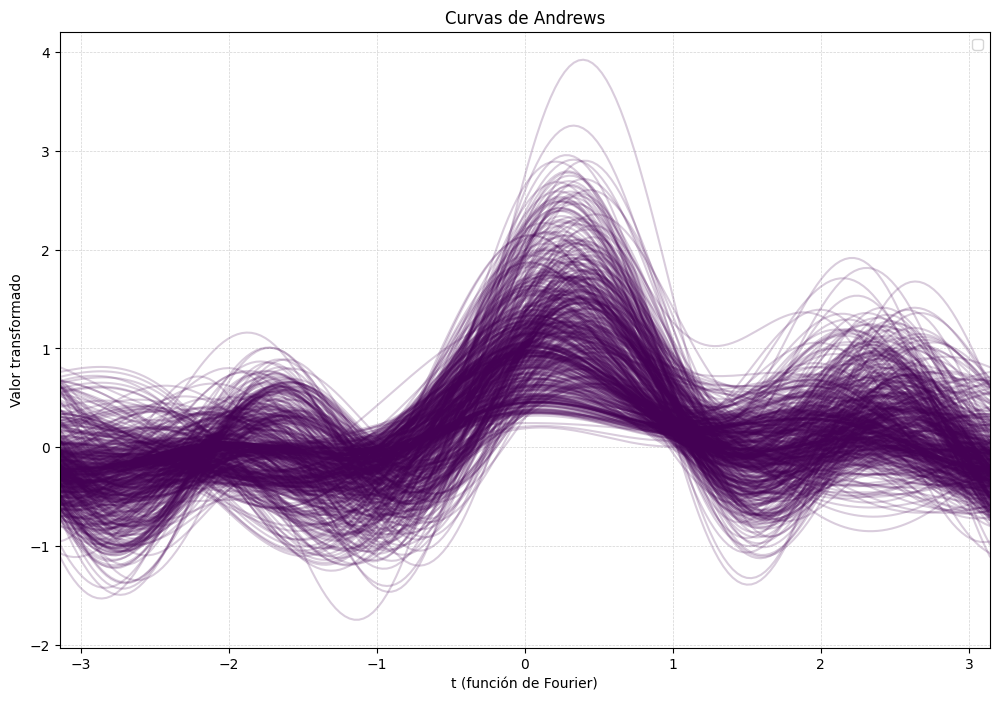

In [15]:
andrews_curve_scaled(df[var_num])

Podemos ver la existencia de valores atípicos, en particular algunos que sobresalen de las demás curvas. 

In [16]:
#Usaremos minima covarianza
def outliers_mcd(df, contamination=0.01, random_state=1989, support_fraction=None):
    model = MCD(contamination=contamination, random_state=random_state, support_fraction=support_fraction)
    model.fit(df)
    preds = model.predict(df)
    return df[preds == 1]  #detectar

In [17]:
df_outliers = outliers_mcd(df[var_num])

In [18]:
#Visualizamos en el df original
df.loc[df_outliers.index]

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished


In [19]:
#Eliminamos los atipicos
df.drop(df_outliers.index, inplace=True)

In [20]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished
10,9800000,13200,3,1,2,yes,no,yes,no,yes,2,yes,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


c:\Users\raulb\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\plotting\_matplotlib\misc.py:286: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



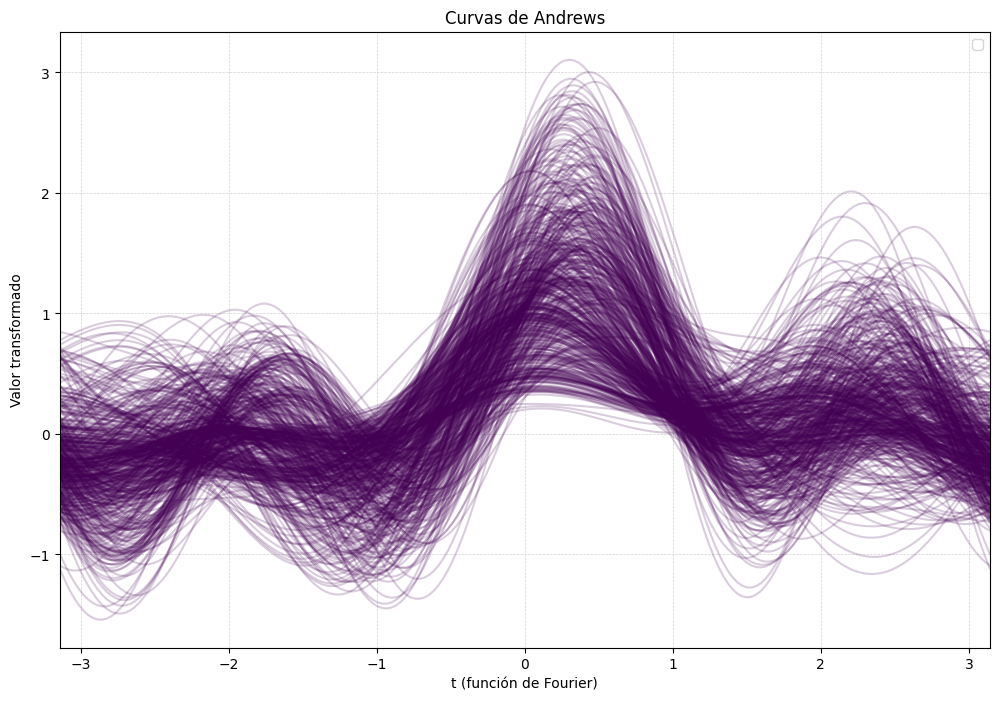

In [21]:
andrews_curve_scaled(df[var_num])

## Modelado

### Partición, codificación y escalamiento

In [22]:
#Variables explicativas y variable objetivo
y = df["price"]
X = df.drop(columns=["price", "hotwaterheating"])

In [23]:
#Codificacion 
X = pd.get_dummies(X, columns=["mainroad", "basement", "guestroom", "furnishingstatus", "prefarea", "airconditioning"], drop_first=True)

In [24]:
#Particion
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1989)

In [25]:
#Escalamiento
var_num = ["area", "bedrooms", "bathrooms", "stories", "parking"]
scaler = MinMaxScaler()

#Ajustamos solo con train
scaler.fit(X_train)

#Transformar train y test
X_train[var_num] = scaler.fit_transform(X_train[var_num])
X_test[var_num] = scaler.transform(X_test[var_num])

### Regresiones

In [26]:
def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return rmse, mae, mape

In [30]:
# Espacio de búsqueda de hiperparámetros
param_dist = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': np.logspace(-3, 3, 15),
    'gamma': ['scale', 'auto'] + list(np.logspace(-3, 2, 6)),
    'degree': [2, 3, 4, 5],
    'coef0': np.linspace(0, 1, 5)
}

In [31]:
# Modelo base
svr = SVR()


In [32]:
random_search = RandomizedSearchCV(
    estimator=svr,
    param_distributions=param_dist,
    n_iter=40,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=1989,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)
best_svr = random_search.best_estimator_

print("\n Mejores parámetros encontrados:")
print(random_search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits

 Mejores parámetros encontrados:
{'kernel': 'poly', 'gamma': np.float64(10.0), 'degree': 2, 'coef0': np.float64(0.0), 'C': np.float64(1000.0)}


In [33]:
y_pred_train = best_svr.predict(X_train)
y_pred_test = best_svr.predict(X_test)

# Métricas
rmse_train, mae_train, mape_train = regression_metrics(y_train, y_pred_train)
rmse_test, mae_test, mape_test = regression_metrics(y_test, y_pred_test)

In [34]:
results = pd.DataFrame({
    'Set': ['Entrenamiento', 'Prueba'],
    'RMSE': [rmse_train, rmse_test],
    'MAE': [mae_train, mae_test],
    'MAPE (%)': [mape_train, mape_test]
})

display(results)

print("\n✅ Entrenamiento y evaluación completados.")

,Set,RMSE,MAE,MAPE (%)
0,Entrenamiento,"952,981.553","650,093.972",14.588
1,Prueba,"1,128,753.024","798,060.689",17.897



✅ Entrenamiento y evaluación completados.
